In [1]:
import h5py as h5 
import matplotlib.pyplot as plt
import numpy as np
import os 
from PMT_analysis_utils import * 
plt.style.use('../../utils/dune.mplstyle')

DEBUG_MAX = 10 

In [2]:
LRS_DIRECTORY = "/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_ambe_bin2/one_trig_32us_window/"
os.listdir(LRS_DIRECTORY)

['mpd_run_data_rctl_615_p85.FLOW.hdf5',
 'mpd_run_data_rctl_616_p34.FLOW.hdf5',
 'mpd_run_data_rctl_615_p42.FLOW.hdf5',
 'mpd_run_data_rctl_616_p90.FLOW.hdf5',
 'mpd_run_data_rctl_615_p153.FLOW.hdf5',
 'mpd_run_data_rctl_617_p8.FLOW.hdf5',
 'mpd_run_data_rctl_616_p135.FLOW.hdf5',
 'mpd_run_data_rctl_616_p122.FLOW.hdf5',
 'mpd_run_data_rctl_615_p197.FLOW.hdf5',
 'mpd_run_data_rctl_617_p3.FLOW.hdf5',
 'mpd_run_data_rctl_615_p57.FLOW.hdf5',
 'mpd_run_data_rctl_615_p117.FLOW.hdf5',
 'mpd_run_data_rctl_615_p148.FLOW.hdf5',
 'mpd_run_data_rctl_615_p23.FLOW.hdf5',
 'mpd_run_data_rctl_616_p121.FLOW.hdf5',
 'mpd_run_data_rctl_617_p44.FLOW.hdf5',
 'mpd_run_data_rctl_616_p152.FLOW.hdf5',
 'mpd_run_data_rctl_616_p130.FLOW.hdf5',
 'mpd_run_data_rctl_616_p88.FLOW.hdf5',
 'mpd_run_data_rctl_615_p184.FLOW.hdf5',
 'mpd_run_data_rctl_616_p138.FLOW.hdf5',
 'mpd_run_data_rctl_615_p172.FLOW.hdf5',
 'mpd_run_data_rctl_615_p154.FLOW.hdf5',
 'mpd_run_data_rctl_615_p155.FLOW.hdf5',
 'mpd_run_data_rctl_616_p38.

In [3]:
# Make function that does this job far file, then we iterate over each set of files
# Beware of normalization


def analysis_PMT_file(input_file):
    out_dataset = {}
    fprompt = []
    amplitude = [] 
    file = h5.File(input_file, "r")
    light_ev = file['light/events/data']
    waveforms = file['light/wvfm/data']['samples']
    total_evs = len(light_ev)

    # We get only the first 600 ticks
    PMT_ADC = 0
    PMT_CHAN = 16 
    PMT_waveforms_pre = waveforms[:,PMT_ADC,PMT_CHAN,0:600]

    # Baseline correction
    PMT_waveforms = thd_correct(PMT_waveforms_pre)*-1
    print(f"Number of light events on this file {total_evs}")
    for ev in range(total_evs):
        amplitude.append(np.max(PMT_waveforms[ev]))
        fp=FPrompt_calculation(PMT_waveforms[ev])
        fprompt.append(fp)
    out_dataset["amplitude"] = amplitude
    out_dataset["fprompt"] =  fprompt
    out_dataset["ntriggers"] = total_evs

    return out_dataset




In [4]:
fprompt_source_out = [] 
amplitude_source_out = [] 
n_triggers_source_out = [] 

LRS_DIRECTORY_OUT = "/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_ambe_bin3/one_pmt_trig_no_source/"

test_index = 0 
for file in os.listdir(LRS_DIRECTORY_OUT):
    if(test_index==DEBUG_MAX):break
    print(file)
    out_data = analysis_PMT_file(LRS_DIRECTORY_OUT + file)
    fprompt_source_out.extend(out_data["fprompt"])
    amplitude_source_out.extend(out_data["amplitude"])
    n_triggers_source_out.append(out_data["ntriggers"])
    test_index+=1


mpd_run_data_rctl_639_p63.FLOW.hdf5
Number of light events on this file 1606
mpd_run_data_rctl_639_p70.FLOW.hdf5
Number of light events on this file 1560
mpd_run_data_rctl_639_p77.FLOW.hdf5
Number of light events on this file 1633
mpd_run_data_rctl_639_p67.FLOW.hdf5
Number of light events on this file 1572
mpd_run_data_rctl_639_p20.FLOW.hdf5
Number of light events on this file 1541
mpd_run_data_rctl_639_p6.FLOW.hdf5
Number of light events on this file 1666
mpd_run_data_rctl_639_p66.FLOW.hdf5
Number of light events on this file 1624
mpd_run_data_rctl_639_p49.FLOW.hdf5
Number of light events on this file 1636
mpd_run_data_rctl_639_p3.FLOW.hdf5
Number of light events on this file 1601
mpd_run_data_rctl_639_p69.FLOW.hdf5
Number of light events on this file 1653


In [5]:
# Source IN

fprompt_source_in = []
amplitude_source_in = []
n_triggers_source_in = [] 

LRS_DIRECTORY_IN = "/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_ambe_bin2/one_trig_32us_window/" 


test_index = 0 
for file in os.listdir(LRS_DIRECTORY_IN):
    if(test_index==DEBUG_MAX):break
    print(file)
    out_data = analysis_PMT_file(LRS_DIRECTORY_IN + file)
    fprompt_source_in.extend(out_data["fprompt"])
    amplitude_source_in.extend(out_data["amplitude"])
    n_triggers_source_in.append(out_data["ntriggers"])
    test_index+=1

mpd_run_data_rctl_615_p85.FLOW.hdf5


Number of light events on this file 3488
mpd_run_data_rctl_616_p34.FLOW.hdf5
Number of light events on this file 3433
mpd_run_data_rctl_615_p42.FLOW.hdf5
Number of light events on this file 3681
mpd_run_data_rctl_616_p90.FLOW.hdf5
Number of light events on this file 3514
mpd_run_data_rctl_615_p153.FLOW.hdf5
Number of light events on this file 3509
mpd_run_data_rctl_617_p8.FLOW.hdf5
Number of light events on this file 3390
mpd_run_data_rctl_616_p135.FLOW.hdf5
Number of light events on this file 3526
mpd_run_data_rctl_616_p122.FLOW.hdf5
Number of light events on this file 3361
mpd_run_data_rctl_615_p197.FLOW.hdf5
Number of light events on this file 3521
mpd_run_data_rctl_617_p3.FLOW.hdf5
Number of light events on this file 3497


In [6]:
print(f"Total exposure: {90*DEBUG_MAX} s")

Total exposure: 900 s


In [7]:
print("Stats for triggers...")
print(f"Mean number of triggers: {np.mean(n_triggers_source_out)}")
print(f"Frequency: {np.mean(n_triggers_source_out)/90.} Hz")

Stats for triggers...
Mean number of triggers: 1609.2
Frequency: 17.88 Hz


In [8]:
print("Stats for triggers...")
print(f"Mean number of triggers: {np.mean(n_triggers_source_in)}")
print(f"Frequency: {np.mean(n_triggers_source_in)/90.} Hz")

Stats for triggers...
Mean number of triggers: 3492.0
Frequency: 38.8 Hz


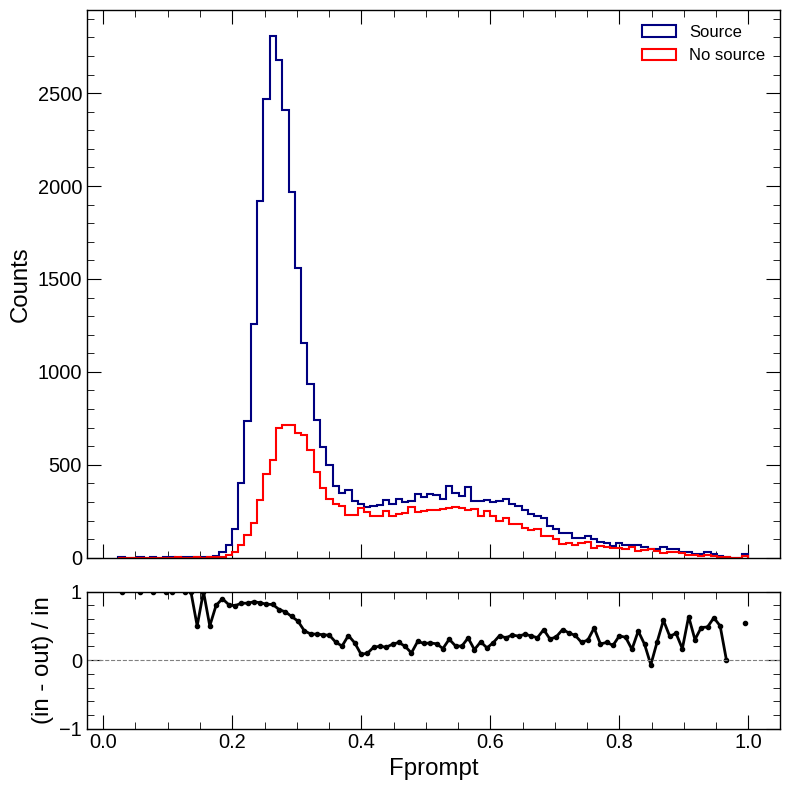

In [9]:
import numpy as np
import matplotlib.pyplot as plt

nbins = 100

# Compute histograms
counts_in, bin_edges = np.histogram(fprompt_source_in, bins=nbins)
counts_out, _ = np.histogram(fprompt_source_out, bins=bin_edges)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Ratio
ratio = np.zeros_like(counts_in, dtype=float)
nonzero = counts_in > 0
ratio[nonzero] = (counts_in[nonzero] - counts_out[nonzero]) / counts_in[nonzero]
ratio[~nonzero] = np.nan

fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [4, 1]}
)

# Top panel: histograms
ax1.hist(fprompt_source_in, bins=bin_edges, histtype="step", label="Source",color='navy')
ax1.hist(fprompt_source_out, bins=bin_edges, histtype="step", label="No source",color='red')
ax1.set_ylabel("Counts")
ax1.legend()

# Bottom panel: ratio
ax2.plot(bin_centers, ratio, marker='o', linestyle='-', markersize=3)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel("Fprompt")
ax2.set_ylabel("(in - out) / in")
ax2.set_ylim(-1, 1)

plt.tight_layout()
plt.show()


Purity above 5000 ADC = 99.23%


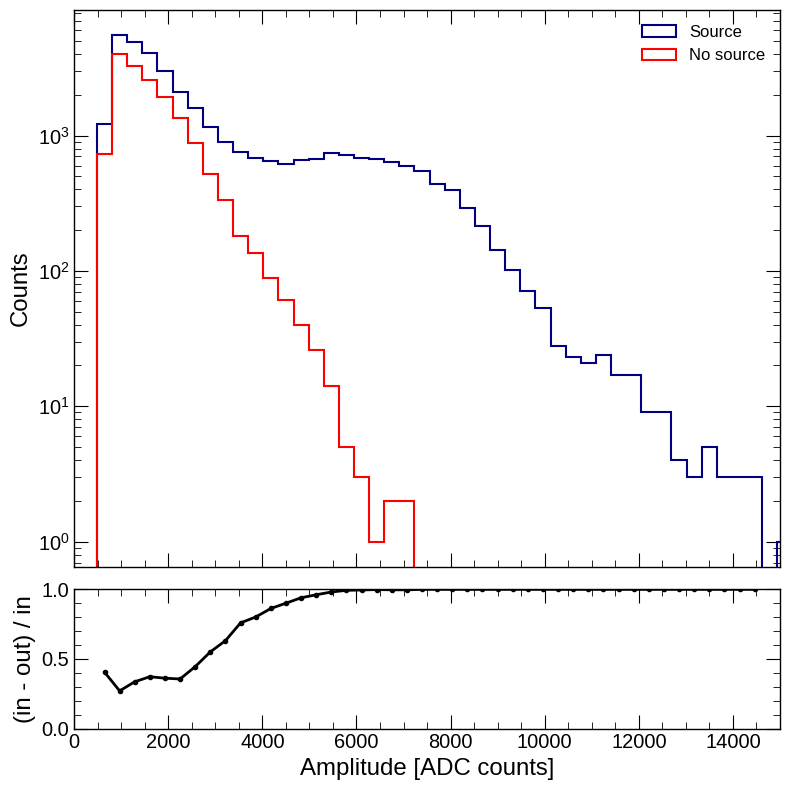

In [10]:

# --- Histogram settings ---
nbins = 100
threshold = 5000  # ADC cut for purity

# Compute histograms (shared bin edges)
counts_in, bin_edges = np.histogram(amplitude_source_in, bins=nbins)
counts_out, _ = np.histogram(amplitude_source_out, bins=bin_edges)

# Bin centers
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# --- Compute purity ---
# Identify bins where bin center is above the threshold
above_cut = bin_centers > threshold

# Sums for purity
sum_in = np.sum(counts_in[above_cut])
sum_out = np.sum(counts_out[above_cut])

if sum_in > 0:
    purity = ((sum_in - sum_out) / sum_in) * 100
else:
    purity = np.nan

print(f"Purity above {threshold} ADC = {purity:.2f}%")

# --- Compute the ratio (in - out)/in ---
ratio = np.zeros_like(counts_in, dtype=float)
nonzero = counts_in > 0
ratio[nonzero] = (counts_in[nonzero] - counts_out[nonzero]) / counts_in[nonzero]
ratio[~nonzero] = np.nan

# --- Figure with height ratio 4:1 ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [4, 1]}
)

# --- Top panel: histograms ---
ax1.hist(amplitude_source_in, bins=bin_edges, histtype="step", label="Source",color='navy')
ax1.hist(amplitude_source_out, bins=bin_edges, histtype="step", label="No source",color='red')
ax1.set_ylabel("Counts")
ax1.set_xlim(0.,15000)
ax1.set_yscale('log')
ax1.legend()

# --- Bottom panel: ratio plot ---
ax2.plot(bin_centers, ratio, marker='o', linestyle='-', markersize=3)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel("Amplitude [ADC counts]")
ax2.set_ylabel("(in - out) / in")
ax2.set_ylim(0, 1)
ax2.set_xlim(0.,15000)

plt.tight_layout()
plt.show()



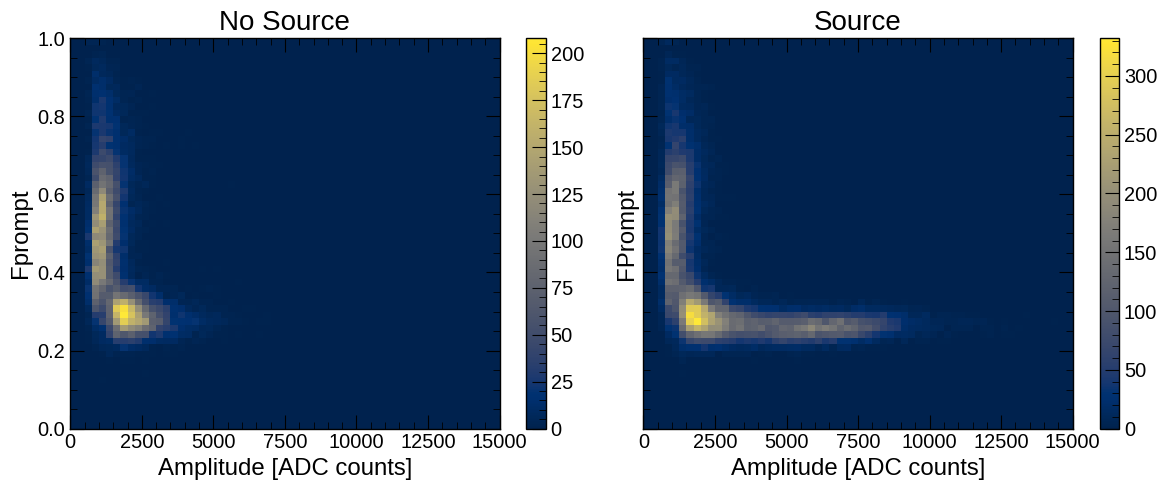

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# User-chosen axis ranges
# -------------------------------
# Example (change these values):
xrange = (0, 15000)      # amplitude range
yrange = (0.0, 1.0)     # fprompt range
# -------------------------------

# Number of bins
nbins_amp = 60
nbins_fpr = 60

# Construct bin edges using provided axis limits
xedges = np.linspace(xrange[0], xrange[1], nbins_amp + 1)
yedges = np.linspace(yrange[0], yrange[1], nbins_fpr + 1)

# Compute 2D histograms using the chosen ranges
H_out, _, _ = np.histogram2d(
    amplitude_source_out,
    fprompt_source_out,
    bins=[xedges, yedges]
)

H_in, _, _ = np.histogram2d(
    amplitude_source_in,
    fprompt_source_in,
    bins=[xedges, yedges]
)

# --- Create figure with two panels ---
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5), sharex=True, sharey=True
)

# --- Left panel: No source ---
mesh1 = ax1.pcolormesh(
    xedges, yedges, H_out.T,
    shading='auto'
)
ax1.set_title("No Source",size=20)
ax1.set_xlabel("Amplitude [ADC counts]")
ax1.set_ylabel("Fprompt")
cbar1 = plt.colorbar(mesh1, ax=ax1)

# --- Right panel: Source ---
mesh2 = ax2.pcolormesh(
    xedges, yedges, H_in.T,
    shading='auto'
)
ax2.set_title("Source",size=20)
ax2.set_ylabel("FPrompt")
ax2.set_xlabel("Amplitude [ADC counts]")
cbar2 = plt.colorbar(mesh2, ax=ax2)

# Apply the axis ranges
ax1.set_xlim(xrange)
ax1.set_ylim(yrange)

plt.tight_layout()
plt.show()


[1. 1. 1. ... 2. 1. 1.]
(array([ 0,  0,  0, ..., 99, 99, 99]), array([ 0,  1,  2, ..., 97, 98, 99]))


/tmp/ipykernel_645851/1388792505.py:34: RuntimeWarning: divide by zero encountered in divide
  H_diff = (H_in - H_out)/H_in
/tmp/ipykernel_645851/1388792505.py:34: RuntimeWarning: invalid value encountered in divide
  H_diff = (H_in - H_out)/H_in


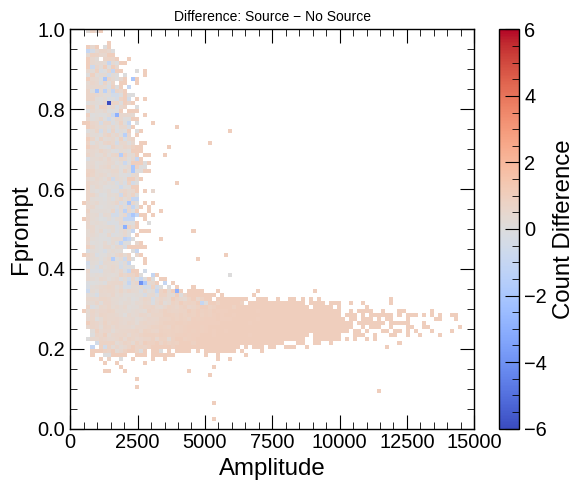

In [ ]:
import matplotlib.colors as colors
# -------------------------------
# User-chosen axis ranges
# -------------------------------
xrange = (0, 15000)      # amplitude limits
yrange = (0.0, 1.0)     # fprompt limits
# -------------------------------

# Number of bins
nbins_amp = 100
nbins_fpr = 100

# Construct bin edges
xedges = np.linspace(xrange[0], xrange[1], nbins_amp + 1)
yedges = np.linspace(yrange[0], yrange[1], nbins_fpr + 1)

# Compute 2D histograms
H_out, _, _ = np.histogram2d(
    amplitude_source_out,
    fprompt_source_out,
    bins=[xedges, yedges]
)

H_in, _, _ = np.histogram2d(
    amplitude_source_in,
    fprompt_source_in,
    bins=[xedges, yedges]
)



# Difference histogram
H_diff = (H_in - H_out)/H_in

print(np.where(H_diff!=np.isnan))
# -------------------------------------------------------
# Make a standalone figure for the difference heatmap
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# Center colormap around zero
#max_abs = np.max(np.abs(H_diff))

mesh = ax.pcolormesh(
    xedges, yedges, H_diff.T,
    shading='auto',
    cmap='coolwarm',
    norm=colors.CenteredNorm()  # symmetric colormap around zero
)

ax.set_title("Difference: Source − No Source")
ax.set_xlabel("Amplitude")
ax.set_ylabel("Fprompt")
ax.set_xlim(xrange)
ax.set_ylim(yrange)

cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("Count Difference")

plt.tight_layout()
plt.show()
